<a href="https://colab.research.google.com/github/sanchezmicaela/Aprendizaje_Automatico/blob/main/6-evaluacion_modelos-micaela-sanchez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre: Micaela Arami Sánchez Arce

CI: 5572584

# Clase 6 — Evaluación y Selección de Modelos
**Profesor:** Prof. Dr. Pástor E Pérez Estigarribia (adaptado)  
**Objetivo del notebook:** consolidar conceptos de evaluación (matrices, ROC/AUC), validación cruzada y búsqueda de hiperparámetros (Grid / Randomized), y practicar con demos y desafíos reproducibles en Colab.  
**Archivos generados:** figuras en `figures/`, resúmenes en `outputs/`.  


## Objetivos de aprendizaje
Al finalizar este notebook el estudiante podrá:
- Explicar y calcular métricas de clasificación: accuracy, precision, recall, F1 y AUC.
- Interpretar una matriz de confusión y una curva ROC.
- Aplicar validación cruzada (k‑fold, stratified) y entender su utilidad.
- Ejecutar GridSearchCV y RandomizedSearchCV; comparar cobertura, coste y resultados.
- Implementar y evaluar un StackingClassifier y un árbol ponderado para datos desbalanceados.
- Diseñar una estrategia práctica de búsqueda de hiperparámetros (incluyendo estrategia híbrida).


## **3 — Imports y configuración**

In [ ]:
# Imports y configuración inicial
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='notebook')

from sklearn import datasets
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_val_score, GridSearchCV, RandomizedSearchCV,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Crear carpetas de salida
os.makedirs('figures', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Semilla reproducible
RND = 42
np.random.seed(RND)


# **BLOQUE A — Implementaciones demostrativas**

### Demo A — ROC con validación cruzada
Objetivo: visualizar la curva ROC media y su variabilidad usando k‑fold CV; calcular AUC por fold y guardar figura `figures/roc_crossval.png`.


## **A.1 — Demo A: código**

In [ ]:
# Demo A: ROC con validación cruzada (Colab)
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn import svm

# Dataset binario más difícil de clasificar (versicolor vs virginica)
iris = datasets.load_iris()
# Seleccionar solo las clases versicolor (1) y virginica (2)
X = iris.data[iris.target != 0]
y = iris.target[iris.target != 0]
# Re-mapear las etiquetas a 0 y 1 para la clasificación binaria
y[y == 1] = 0 # versicolor se convierte en 0
y[y == 2] = 1 # virginica se convierte en 1

# Añadir ruido opcional para mayor dificultad (opcional)
rng = np.random.RandomState(RND)
X = np.c_[X, rng.randn(X.shape[0], 50)]

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=RND)
classifier = SVC(kernel='linear', probability=True, random_state=RND)

tprs, aucs = [], []
mean_fpr = np.linspace(0, 1, 100)

for i, (train, test) in enumerate(cv.split(X, y), 1):
    probas_ = classifier.fit(X[train], y[train]).predict_proba(X[test])
    fpr, tpr, _ = roc_curve(y[test], probas_[:, 1])
    auc_score = auc(fpr, tpr)
    aucs.append(auc_score)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.figure(figsize=(7,6))
for i, tpr in enumerate(tprs, 1):
    plt.plot(mean_fpr, tpr, color='gray', alpha=0.3, lw=1, label=f'ROC fold {i} (AUC={aucs[i-1]:.2f})')
plt.plot(mean_fpr, mean_tpr, color='b', lw=2, label=f'Mean ROC (AUC={mean_auc:.2f} ± {std_auc:.2f})')
plt.fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr,0), np.minimum(mean_tpr+std_tpr,1), color='b', alpha=0.2)
plt.plot([0,1], [0,1], linestyle='--', color='k', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC con validación cruzada')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.savefig('figures/roc_crossval.png', dpi=150)
plt.show()

# Guardar resumen
with open('outputs/roc_crossval_summary.json', 'w') as f:
    json.dump({'aucs': [float(a) for a in aucs], 'mean_auc': float(mean_auc), 'std_auc': float(std_auc)}, f)
print('AUCs por fold:', np.round(aucs,3))
print('AUC medio ± std:', round(mean_auc,3), '±', round(std_auc,3))

**Preguntas (Demo A)**  
1. ¿Por qué interpolamos TPR sobre una malla común de FPR antes de promediar?  
2. Si la banda de desviación es amplia en FPR baja, ¿qué implicación práctica tiene para un sistema que requiere muy pocos falsos positivos?  
3. ¿Qué diferencia hay entre AUC medio (CV) y AUC calculado sobre un test final tras tuning? ¿Por qué usar nested CV si hacemos selección de hiperparámetros?


## **A.2 — Demo B: Stacking ensemble comparativo**

### Demo B — Stacking ensemble comparativo
Objetivo: comparar rendimiento de modelos base y del StackingClassifier usando cross_val_score; guardar `figures/stacking_comparison.png`.


## **A.2 — Demo B: código**

In [ ]:
# Demo B: Stacking ensemble comparativo
from sklearn.datasets import make_classification
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.ensemble import StackingClassifier

X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=RND)

models = {
    'lr': LogisticRegression(max_iter=1000, random_state=RND),
    'knn': KNeighborsClassifier(),
    'cart': DecisionTreeClassifier(random_state=RND),
    'svm': SVC(probability=True, random_state=RND),
    'bayes': GaussianNB()
}

level0 = [('lr', LogisticRegression(max_iter=1000)),
          ('knn', KNeighborsClassifier()),
          ('cart', DecisionTreeClassifier(random_state=RND)),
          ('svm', SVC(probability=True, random_state=RND)),
          ('bayes', GaussianNB())]
meta = LogisticRegression(max_iter=1000)
stacking = StackingClassifier(estimators=level0, final_estimator=meta, cv=5, n_jobs=-1)
models['stacking'] = stacking

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RND)
results, names = [], []
for name, model in models.items():
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print(f'>{name} {np.mean(scores):.3f} ({np.std(scores):.3f})')

plt.figure(figsize=(9,5))
plt.boxplot(results, labels=names, showmeans=True)
plt.ylabel('Accuracy')
plt.title('Comparación modelos base vs stacking')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/stacking_comparison.png', dpi=150)
plt.show()


**Preguntas (Demo B)**  
1. ¿Qué papel juega el `final_estimator` en StackingClassifier y por qué suele elegirse un modelo simple como regresión logística?  
2. ¿Por qué es importante usar `cv` dentro de StackingClassifier al generar las predicciones para el metamodelo?  
3. Si el stacking no mejora respecto al mejor modelo base, ¿qué posibles causas investigarías?


## **Demo C — GridSearch vs RandomizedSearch (comparativa)**
Objetivo: comparar cobertura del espacio, tiempo y calidad de la mejor configuración entre GridSearchCV y RandomizedSearchCV usando SVC sobre Digits. Guardar heatmap y boxplot en `figures/`.

### **A.3 — Demo C: código**


In [ ]:
# Demo C: Grid vs Randomized Search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

digits = datasets.load_digits()
X, y = digits.data, digits.target

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=RND))])

param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [1e-3, 1e-2, 1e-1, 1],
    'svc__kernel': ['rbf']
}
param_dist = {
    'svc__C': loguniform(1e-2, 1e3),
    'svc__gamma': loguniform(1e-4, 1e0),
    'svc__kernel': ['rbf']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

# GridSearch
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', return_train_score=True, n_jobs=-1)
t0 = time.time()
grid.fit(X, y)
t_grid = time.time() - t0

# RandomizedSearch with same budget
n_iter = len(param_grid['svc__C']) * len(param_grid['svc__gamma'])
rand = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=n_iter, cv=cv, scoring='accuracy', random_state=RND, n_jobs=-1)
t1 = time.time()
rand.fit(X, y)
t_rand = time.time() - t1

summary = {
    'grid_best_params': grid.best_params_,
    'grid_best_score': float(grid.best_score_),
    'grid_time_s': float(t_grid),
    'rand_best_params': rand.best_params_,
    'rand_best_score': float(rand.best_score_),
    'rand_time_s': float(t_rand),
    'n_grid_evals': n_iter,
    'n_rand_evals': n_iter
}
with open('outputs/grid_vs_rand_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Grid best score:", grid.best_score_, "time (s):", round(t_grid,2))
print("Random best score:", rand.best_score_, "time (s):", round(t_rand,2))

# Heatmap del grid
grid_results = pd.DataFrame(grid.cv_results_)
grid_results['param_svc__gamma_str'] = grid_results['param_svc__gamma'].astype(str)
pivot = grid_results.pivot_table(values='mean_test_score', index='param_svc__C', columns='param_svc__gamma_str')

plt.figure(figsize=(7,5))
plt.title('GridSearch mean_test_score heatmap')
plt.imshow(pivot.values.astype(float), cmap='viridis', aspect='auto')
plt.colorbar(label='mean_test_score')
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.savefig('figures/grid_heatmap.png', dpi=150)
plt.show()

# Boxplot comparativo
rand_results = pd.DataFrame(rand.cv_results_)
plt.figure(figsize=(6,5))
plt.boxplot([grid_results['mean_test_score'], rand_results['mean_test_score']], labels=['Grid', 'Randomized'], showmeans=True)
plt.ylabel('mean_test_score (cv)')
plt.title('Comparación distribución de mean_test_score')
plt.tight_layout()
plt.savefig('figures/grid_vs_rand_boxplot.png', dpi=150)
plt.show()

# Guardar resultados completos
grid_results.to_csv('outputs/grid_cv_results.csv', index=False)
rand_results.to_csv('outputs/rand_cv_results.csv', index=False)


**Preguntas (Demo C)**  
1. ¿Qué ventaja principal tiene GridSearchCV frente a RandomizedSearchCV?  
2. ¿En qué situaciones RandomizedSearchCV suele encontrar mejores configuraciones con menor coste?  
3. ¿Cómo afecta la elección de la distribución (por ejemplo loguniform) en RandomizedSearchCV al resultado?  
4. ¿Qué indica una celda del heatmap con score alto en GridSearch?  
5. ¿Por qué fijamos `n_iter` de RandomizedSearch igual al número de combinaciones del grid en esta demo?


# **GridSearchCV para MLPClassifier**

In [ ]:
# GridSearch para MLPClassifier (Colab)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn import datasets
import json, time, os
os.makedirs('outputs', exist_ok=True)

RND = 42
X, y = datasets.load_digits(return_X_y=True)
pipe = Pipeline([('scaler', StandardScaler()), ('mlp', MLPClassifier(random_state=RND, max_iter=300))])

param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (100,50)],
    'mlp__alpha': [1e-4, 1e-3, 1e-2],
    'mlp__learning_rate_init': [1e-3, 1e-2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True)
t0 = time.time()
grid.fit(X, y)
t_grid = time.time() - t0

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
with open('outputs/mlp_grid_summary.json','w') as f:
    json.dump({'best_params': grid.best_params_, 'best_score': float(grid.best_score_), 'time_s': t_grid}, f)


Best params: {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (100,), 'mlp__learning_rate_init': 0.001}
Best CV score: 0.9821928195605075


In [ ]:
## RND es simplemente una variable que contiene la semilla (seed) para los generadores de números aleatorios
import numpy as np
RND = 42
np.random.seed(RND)
print(np.random.rand(3))  # siempre dará la misma secuencia si RND no cambia

# 42 es una elección arbitraria y muy habitual en ejemplos y tutoriales (referencia cultural a The Hitchhiker’s Guide to the Galaxy).


[0.37454012 0.95071431 0.73199394]


**Actividad**

Utiliza la función explicar código y el asistente de notebookLM para relatar con tus propia palabras el flujo de trabajo implementado en la celda anterior:

# **RandomizedSearchCV para MLPClassifier**

In [ ]:
# RandomizedSearch para MLPClassifier (Colab)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform
import json, time

param_dist = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (100,50), (200,)],
    'mlp__alpha': loguniform(1e-5, 1e-1),
    'mlp__learning_rate_init': loguniform(1e-4, 1e-1)
}

rand = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=20, cv=cv, scoring='accuracy', random_state=RND, n_jobs=-1)
t0 = time.time()
rand.fit(X, y)
t_rand = time.time() - t0

print("Random best params:", rand.best_params_)
print("Random best CV score:", rand.best_score_)
with open('outputs/mlp_rand_summary.json','w') as f:
    json.dump({'best_params': rand.best_params_, 'best_score': float(rand.best_score_), 'time_s': t_rand}, f)


Random best params: {'mlp__alpha': np.float64(6.788387912421223e-05), 'mlp__hidden_layer_sizes': (200,), 'mlp__learning_rate_init': np.float64(0.00035856126103454)}
Random best CV score: 0.9849721448467967


**Actividad**

Utiliza la función explicar código y el asistente de notebookLM para relatar con tus propia palabras el flujo de trabajo implementado en la celda anterior:

# **Nested CV para estimación robusta con MLP**

In [ ]:
# Nested CV: outer CV para estimación, inner CV para selección (Colab)
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import numpy as np

# usar param_grid reducido por tiempo
inner_grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

scores = cross_val_score(inner_grid, X, y, cv=outer_cv, scoring='accuracy', n_jobs=-1)
print("Nested CV scores:", np.round(scores,3))
print("Nested CV mean ± std:", np.round(scores.mean(),3), "±", np.round(scores.std(),3))


Nested CV scores: [0.981 0.981 0.983 0.981 0.972]
Nested CV mean ± std: 0.979 ± 0.004


**Actividad**

Utiliza la función explicar código y el asistente de notebookLM para relatar con tus propia palabras el flujo de trabajo implementado en la celda anterior:

# **ROC con CV para MLP (guardar figura)**

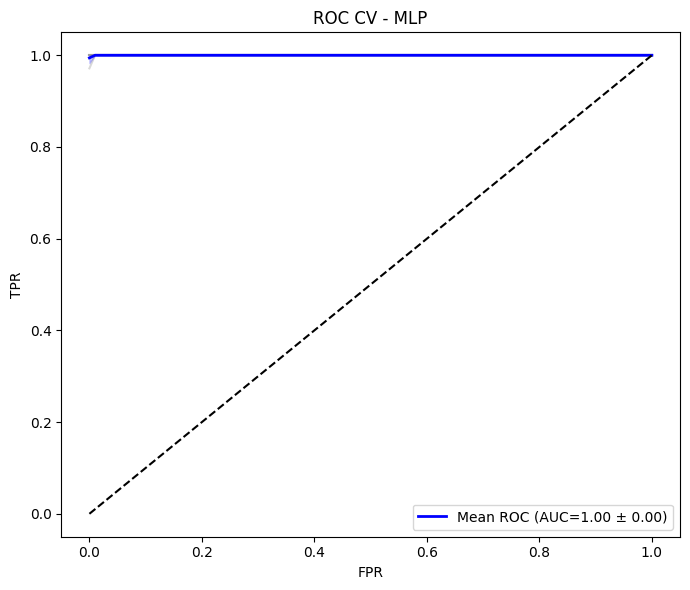

In [ ]:
# ROC con CV para MLP (guardar figura)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# binarizar para clase vs resto (ejemplo con dígitos: clase 0 vs resto)
y_bin = (y == 0).astype(int)
clf = Pipeline([('scaler', StandardScaler()), ('mlp', MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=RND))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

tprs, aucs = [], []
mean_fpr = np.linspace(0,1,100)
for train, test in cv.split(X, y_bin):
    prob = clf.fit(X[train], y_bin[train]).predict_proba(X[test])[:,1]
    fpr, tpr, _ = roc_curve(y_bin[test], prob)
    aucs.append(auc(fpr,tpr))
    tprs.append(np.interp(mean_fpr, fpr, tpr))
mean_tpr = np.mean(tprs, axis=0)
plt.figure(figsize=(7,6))
for i, tpr in enumerate(tprs):
    plt.plot(mean_fpr, tpr, color='gray', alpha=0.3)
plt.plot(mean_fpr, mean_tpr, color='b', lw=2, label=f'Mean ROC (AUC={np.mean(aucs):.2f} ± {np.std(aucs):.2f})')
plt.fill_between(mean_fpr, np.maximum(mean_tpr-np.std(tprs,axis=0),0), np.minimum(mean_tpr+np.std(tprs,axis=0),1), color='b', alpha=0.2)
plt.plot([0,1],[0,1],'--',color='k')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC CV - MLP'); plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig('mlp_roc_cv.png', dpi=150); plt.show()


# **BLOQUE B — Actividades de desafío (para entregar)**

## Actividades de evaluación (entregables)
Realiza las tareas siguientes en el mismo notebook. Guarda figuras en `figures/` y tablas/resultados en `outputs/`. Entrega el notebook ejecutado (.ipynb) y un informe breve (Markdown) con respuestas y conclusiones.


**Desafío 1 — ROC comparativa**  
- Reproducir Demo A para tres clasificadores: LogisticRegression, RandomForestClassifier, SVC (RBF).  
- Entregables: `figures/roc_crossval_lr.png`, `figures/roc_crossval_rf.png`, `figures/roc_crossval_svc.png` y `outputs/roc_summary.csv` (AUC por fold y estadísticas).  
- Informe (5–8 líneas): cuál modelo tiene mejor AUC medio y cuál es más estable.


**Desafío 2 — Stacking + Pipelines + GridSearch**  
- Construir pipelines (StandardScaler + modelo) para cada base.  
- Crear StackingClassifier con pipelines como estimators.  
- Ejecutar GridSearchCV para ajustar `final_estimator__C` (LogisticRegression) y comparar con stacking sin preprocesado.  
- Entregables: `figures/stacking_grid.png`, `outputs/stacking_grid_results.csv`.  
- Informe: justificar preprocesado y comentar mejora (o ausencia de ella).


**Desafío 3 — Árbol ponderado (clases desbalanceadas)**  
- Generar dataset sintético con `make_classification` con proporción 1:100.  
- Ejecutar GridSearchCV sobre `class_weight` (valores propuestos en material).  
- Evaluar con RepeatedStratifiedKFold y ROC AUC.  
- Entregables: `outputs/grid_class_weight_results.csv` y breve informe (máx 1 página) con la mejor configuración y su interpretación.


**Desafío 4 — Nested CV**  
- Elegir un problema (Digits o dataset propio).  
- Realizar selección de modelo e hiperparámetros con GridSearchCV dentro de un outer CV (nested CV) para estimar rendimiento final.  
- Entregables: `outputs/nested_cv_summary.csv` con métricas por fold (media y std).  
- Informe: explicar por qué nested CV evita sesgo optimista.


## Preguntas de evaluación (responder en el notebook)
1. ¿Qué métrica elegirías para un problema de detección de fraude y por qué?  
2. ¿Cuándo es preferible usar RandomizedSearch en lugar de GridSearch? Da un ejemplo práctico.  
3. Explica en 3–5 líneas por qué es importante encadenar preprocesado y modelo en un `Pipeline` antes de GridSearch.  
4. ¿Qué es nested CV y en qué escenario es imprescindible usarlo?


## Rúbrica de evaluación (total 100 puntos)

**Criterios y pesos**
- Correctitud técnica del código: **30 pts**  
  Código ejecutable, produce figuras y archivos solicitados, sin errores.
- Interpretación y análisis de resultados: **25 pts**  
  Calidad de las conclusiones, respuestas a preguntas y justificación de decisiones.
- Visualizaciones y entregables: **15 pts**  
  Figuras legibles, nombres exactos, tablas/CSV con resultados.
- Reproducibilidad y buenas prácticas: **15 pts**  
  Uso de `Pipeline`, `random_state`, `cv`, `n_jobs`, documentación de versiones.
- Documentación y presentación: **15 pts**  
  Notebook limpio, celdas Markdown explicativas, informe breve por desafío.

**Niveles de desempeño (ejemplo para Correctitud técnica)**
- Excelente (27–30): Código correcto, genera todos los archivos solicitados.  
- Bueno (21–26): Faltan 1–2 archivos o hay warnings menores.  
- Suficiente (15–20): Errores en algunas funciones; resultados parciales.  
- Insuficiente (0–14): Código no ejecutable o resultados incorrectos.

**Criterios de verificación rápida**
- ¿Se usó `StandardScaler` dentro de `Pipeline` cuando corresponde?  
- ¿Se fijó `random_state` en modelos y CV?  
- ¿Se incluyó `outputs/` con CSV/JSON de resumen?  
- ¿Las figuras están en `figures/` con los nombres solicitados?

**Comentarios del corrector (campo libre)**
- Fortalezas:  
- Áreas de mejora:  
- Recomendaciones para la entrega final:


In [ ]:
# Celda opcional: listar archivos generados
import glob
files = sorted(glob.glob('figures/*') + glob.glob('outputs/*') + glob.glob('*.ipynb'))
print("Archivos generados:")
for f in files:
    print('-', f)


---
## **Desafío 1**


In [1]:
from sklearn import datasets
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import numpy as np
import pandas as pd

RND = 42

iris = datasets.load_iris()

X = iris.data[iris.target != 0]
y = iris.target[iris.target != 0]

y[y == 1] = 0
y[y == 2] = 1

rng = np.random.RandomState(RND)

X = np.c_[
    X,
    rng.randn(X.shape[0], 50)
]

cv = StratifiedKFold(
    n_splits=6,
    shuffle=True,
    random_state=RND
)

print(X.shape)

(100, 54)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

modelos = {
    "LogisticRegression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=1000,
                random_state=RND
            ))
        ]),

    "RandomForest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=RND
        ),

    "SVC_RBF":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                probability=True,
                random_state=RND
            ))
        ])
}

print(modelos.keys())

dict_keys(['LogisticRegression', 'RandomForest', 'SVC_RBF'])


In [3]:
from sklearn.metrics import (
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

def evaluar_roc_cv(modelo, X, y, cv, nombre):

    aucs = []

    mean_fpr = np.linspace(0, 1, 100)

    plt.figure(figsize=(7,6))

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        modelo.fit(
            X_train,
            y_train
        )

        y_score = modelo.predict_proba(X_test)[:,1]

        fpr, tpr, _ = roc_curve(
            y_test,
            y_score
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        aucs.append(roc_auc)

        plt.plot(
            fpr,
            tpr,
            alpha=0.3,
            label=f"Fold {i+1} (AUC={roc_auc:.3f})"
        )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"ROC CV - {nombre}"
    )

    plt.legend(
        fontsize=8
    )

    plt.tight_layout()

    plt.show()

    print(
        f"AUC medio: {np.mean(aucs):.4f}"
    )

    print(
        f"Desvío estándar: {np.std(aucs):.4f}"
    )

    return np.mean(aucs), np.std(aucs)

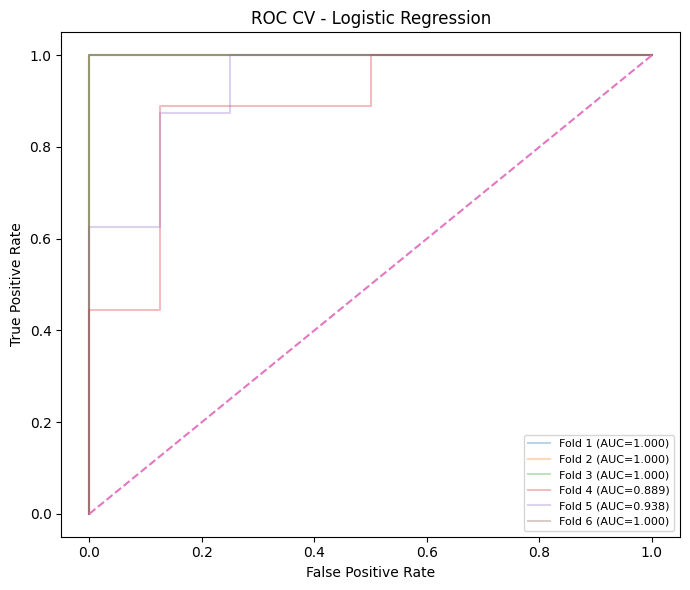

AUC medio: 0.9711
Desvío estándar: 0.0433


In [4]:
auc_log, std_log = evaluar_roc_cv(
    modelos["LogisticRegression"],
    X,
    y,
    cv,
    "Logistic Regression"
)

### Logistic Regression

La Regresión Logística obtuvo un AUC promedio de 0.9711, indicando una excelente capacidad de discriminación entre ambas clases. La mayoría de los folds alcanzaron valores cercanos a 1.0, mostrando un desempeño muy consistente.

El desvío estándar de 0.0433 sugiere una variabilidad baja entre particiones, por lo que el modelo presenta una estabilidad adecuada durante la validación cruzada.

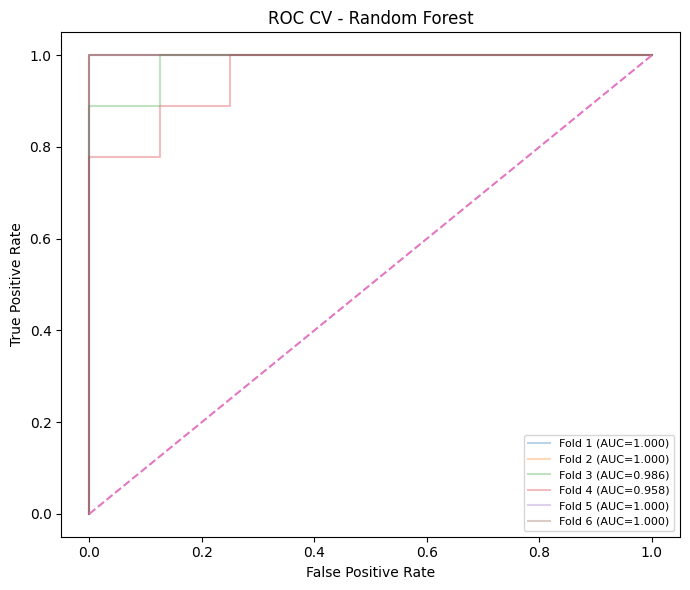

AUC medio: 0.9907
Desvío estándar: 0.0154


In [5]:
auc_rf, std_rf = evaluar_roc_cv(
    modelos["RandomForest"],
    X,
    y,
    cv,
    "Random Forest"
)

### Random Forest

Random Forest obtuvo un AUC promedio de 0.9907, superior al alcanzado por la Regresión Logística. Esto indica una capacidad de clasificación prácticamente perfecta sobre el conjunto de datos evaluado.

Además, presentó un desvío estándar de 0.0154, considerablemente menor que el observado en la Regresión Logística. Esto sugiere que el desempeño del modelo es muy estable entre las diferentes particiones de la validación cruzada.

Los resultados indican que Random Forest logra capturar relaciones más complejas en los datos manteniendo una excelente capacidad de generalización.

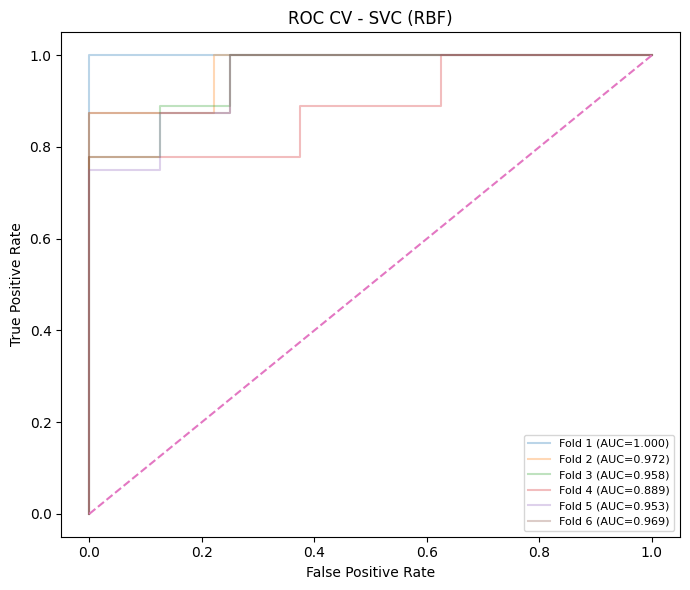

AUC medio: 0.9569
Desvío estándar: 0.0338


In [6]:
auc_svc, std_svc = evaluar_roc_cv(
    modelos["SVC_RBF"],
    X,
    y,
    cv,
    "SVC (RBF)"
)

In [7]:
df_roc = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "SVC (RBF)"
    ],
    "AUC medio": [
        auc_log,
        auc_rf,
        auc_svc
    ],
    "Desvío estándar": [
        std_log,
        std_rf,
        std_svc
    ]
})

df_roc

,Modelo,AUC medio,Desvío estándar
0,Logistic Regression,0.971065,0.043260
1,Random Forest,0.990741,0.015355
2,SVC (RBF),0.956887,0.033849


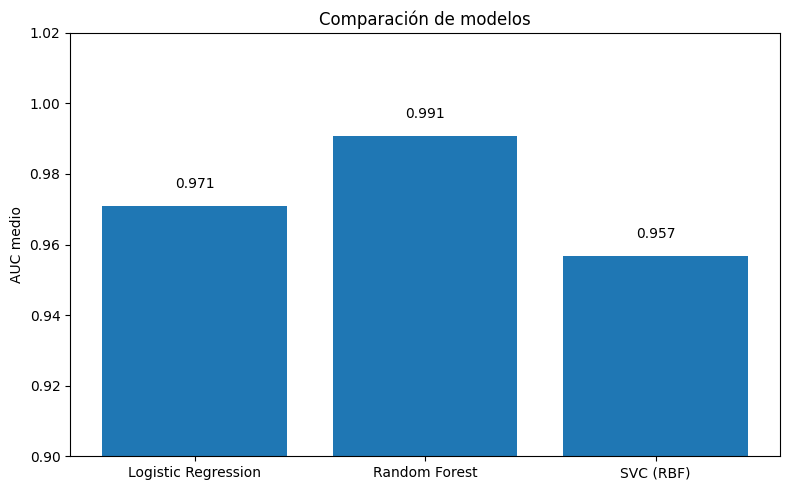

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df_roc["Modelo"],
    df_roc["AUC medio"]
)

plt.ylabel("AUC medio")
plt.title("Comparación de modelos")

for i, valor in enumerate(df_roc["AUC medio"]):
    plt.text(
        i,
        valor + 0.005,
        f"{valor:.3f}",
        ha="center"
    )

plt.ylim(0.90, 1.02)

plt.tight_layout()

plt.savefig(
    "roc_comparacion_modelos.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Comparación de modelos

Se evaluaron tres clasificadores mediante validación cruzada estratificada utilizando curvas ROC y el área bajo la curva (AUC).

Random Forest obtuvo el mejor desempeño general, alcanzando un AUC promedio de 0.9907 y el menor desvío estándar (0.0154), lo que indica una excelente capacidad discriminativa y una elevada estabilidad entre particiones.

La Regresión Logística presentó un AUC promedio de 0.9711, mostrando también un desempeño muy alto, aunque con una variabilidad ligeramente mayor entre folds.

Por su parte, SVC con kernel RBF obtuvo un AUC promedio de 0.9569. Aunque el resultado sigue siendo muy bueno, fue el menor de los tres modelos evaluados.

En conjunto, los tres clasificadores mostraron un rendimiento sobresaliente, siendo Random Forest el modelo con mejor equilibrio entre precisión y estabilidad.

## **Desafío 2**

In [9]:
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold

X_stack, y_stack = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

cv_stack = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Dimensión:", X_stack.shape)
print("Distribución de clases:", np.bincount(y_stack))

Dimensión: (1000, 20)
Distribución de clases: [497 503]


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

estimadores_pipeline = [
    (
        "lr",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=1000,
                random_state=42
            ))
        ])
    ),
    (
        "knn",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ])
    ),
    (
        "tree",
        DecisionTreeClassifier(
            random_state=42
        )
    ),
    (
        "svc",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                probability=True,
                random_state=42
            ))
        ])
    ),
    (
        "bayes",
        GaussianNB()
    )
]

print("Estimadores preparados:", [nombre for nombre, _ in estimadores_pipeline])

Estimadores preparados: ['lr', 'knn', 'tree', 'svc', 'bayes']


In [11]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_pipeline = StackingClassifier(
    estimators=estimadores_pipeline,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    n_jobs=-1
)

stacking_pipeline

StackingClassifier(cv=5,
                   estimators=[('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 LogisticRegression(max_iter=1000,
                                                                    random_state=42))])),
                               ('knn',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 KNeighborsClassifier())])),
                               ('tree',
                                DecisionTreeClassifier(random_state=42)),
                               ('svc',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 SVC(probability=True,
                                                     random_state=42))])),
                               ('bayes', GaussianNB())],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)

In [12]:
estimadores_sin_pipeline = [
    (
        "lr",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "knn",
        KNeighborsClassifier()
    ),
    (
        "tree",
        DecisionTreeClassifier(
            random_state=42
        )
    ),
    (
        "svc",
        SVC(
            probability=True,
            random_state=42
        )
    ),
    (
        "bayes",
        GaussianNB()
    )
]

stacking_sin_pipeline = StackingClassifier(
    estimators=estimadores_sin_pipeline,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    n_jobs=-1
)

stacking_sin_pipeline

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(max_iter=1000,
                                                   random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('tree',
                                DecisionTreeClassifier(random_state=42)),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('bayes', GaussianNB())],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid_stack = {
    "final_estimator__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

grid_stack = GridSearchCV(
    estimator=stacking_pipeline,
    param_grid=param_grid_stack,
    scoring="accuracy",
    cv=cv_stack,
    n_jobs=-1,
    return_train_score=True
)

grid_stack.fit(
    X_stack,
    y_stack
)

print(
    "Mejor parámetro:",
    grid_stack.best_params_
)

print(
    "Mejor accuracy CV:",
    round(grid_stack.best_score_, 4)
)

Mejor parámetro: {'final_estimator__C': 100}
Mejor accuracy CV: 0.948


## Resultados del GridSearch

Se realizó una búsqueda en cuadrícula sobre el parámetro C del estimador final (Logistic Regression) del StackingClassifier.

El mejor resultado se obtuvo con:

- C = 100
- Accuracy promedio = 0.948

Esto indica que una regularización más débil permitió obtener un mejor desempeño del meta-modelo en este conjunto de datos.

In [14]:
from sklearn.model_selection import cross_val_score

scores_con_pipeline = cross_val_score(
    grid_stack.best_estimator_,
    X_stack,
    y_stack,
    scoring="accuracy",
    cv=cv_stack,
    n_jobs=-1
)

scores_sin_pipeline = cross_val_score(
    stacking_sin_pipeline,
    X_stack,
    y_stack,
    scoring="accuracy",
    cv=cv_stack,
    n_jobs=-1
)

print(
    "Stacking con pipeline:",
    round(scores_con_pipeline.mean(), 4),
    "±",
    round(scores_con_pipeline.std(), 4)
)

print(
    "Stacking sin pipeline:",
    round(scores_sin_pipeline.mean(), 4),
    "±",
    round(scores_sin_pipeline.std(), 4)
)

Stacking con pipeline: 0.948 ± 0.0051
Stacking sin pipeline: 0.953 ± 0.0103


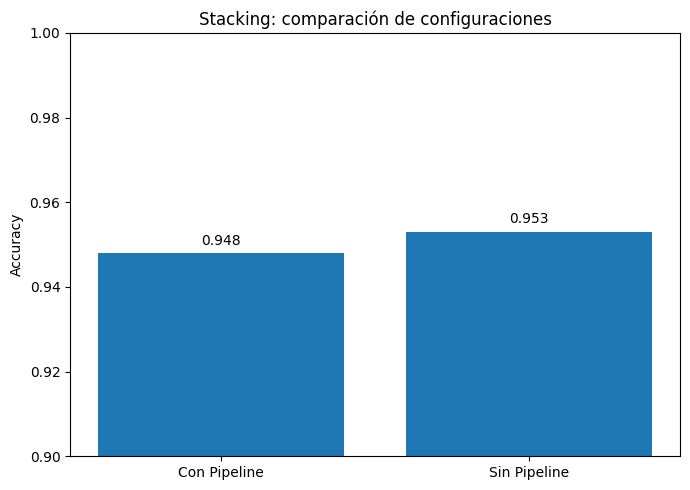

In [17]:
plt.figure(figsize=(7,5))

plt.bar(
    df_stack["Configuración"],
    df_stack["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Stacking: comparación de configuraciones")

for i, valor in enumerate(df_stack["Accuracy"]):
    plt.text(
        i,
        valor + 0.002,
        f"{valor:.3f}",
        ha="center"
    )

plt.ylim(0.90, 1.0)

plt.tight_layout()

plt.savefig(
    "stacking_pipeline_vs_no_pipeline.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Comparación de configuraciones

Se comparó el desempeño del StackingClassifier utilizando pipelines de preprocesamiento y una versión sin escalado previo.

Los resultados obtenidos fueron:

| Configuración | Accuracy medio | Desvío estándar |
|--------------|---------------:|---------------:|
| Con Pipeline | 0.948 | 0.0051 |
| Sin Pipeline | 0.953 | 0.0103 |

La versión sin pipeline obtuvo un accuracy ligeramente superior. Sin embargo, presentó una variabilidad mayor entre particiones.

Por su parte, la configuración con pipeline produjo resultados más estables, lo que puede resultar deseable en escenarios donde la robustez del modelo sea prioritaria.

## **Desafío 3**

In [18]:
from sklearn.datasets import make_classification
import numpy as np

X_imb, y_imb = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_clusters_per_class=2,
    weights=[0.99, 0.01],
    flip_y=0,
    random_state=42
)

print("Dimensión:", X_imb.shape)
print("Distribución de clases:", np.bincount(y_imb))

Dimensión: (5000, 20)
Distribución de clases: [4950   50]


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV
)

pipe_tree = Pipeline([
    (
        "tree",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

cv_tree = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

In [20]:
param_grid_tree = {
    "tree__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 10},
        {0: 1, 1: 25},
        {0: 1, 1: 50},
        {0: 1, 1: 75},
        {0: 1, 1: 100}
    ],
    "tree__max_depth": [
        None,
        3,
        5,
        8
    ],
    "tree__min_samples_leaf": [
        1,
        5,
        10
    ]
}

grid_tree = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    scoring="roc_auc",
    cv=cv_tree,
    n_jobs=-1,
    return_train_score=True
)

grid_tree.fit(
    X_imb,
    y_imb
)

print("Mejores parámetros:")
print(grid_tree.best_params_)

print(
    "Mejor ROC AUC:",
    round(grid_tree.best_score_, 4)
)

Mejores parámetros:
{'tree__class_weight': {0: 1, 1: 25}, 'tree__max_depth': 3, 'tree__min_samples_leaf': 1}
Mejor ROC AUC: 0.7869


In [21]:
import os
import pandas as pd

os.makedirs("outputs", exist_ok=True)

df_tree_results = pd.DataFrame(
    grid_tree.cv_results_
)

columnas_guardar = [
    "param_tree__class_weight",
    "param_tree__max_depth",
    "param_tree__min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_train_score"
]

df_tree_results[
    columnas_guardar
].sort_values(
    "rank_test_score"
).to_csv(
    "outputs/grid_class_weight_results.csv",
    index=False
)

df_tree_results[
    columnas_guardar
].sort_values(
    "rank_test_score"
).head(10)

,param_tree__class_weight,param_tree__max_depth,param_tree__min_samples_leaf,mean_test_score,std_test_score,rank_test_score,mean_train_score
39,"{0: 1, 1: 25}",3,1,0.786879,0.073588,1,0.925422
41,"{0: 1, 1: 25}",3,10,0.786589,0.073649,2,0.924643
40,"{0: 1, 1: 25}",3,5,0.786488,0.073948,3,0.925028
51,"{0: 1, 1: 50}",3,1,0.783451,0.077548,4,0.936682
52,"{0: 1, 1: 50}",3,5,0.783384,0.077579,5,0.936600
53,"{0: 1, 1: 50}",3,10,0.782758,0.077768,6,0.937020
79,"{0: 1, 1: 100}",5,5,0.771865,0.099456,7,0.979927
19,balanced,5,5,0.771545,0.098908,8,0.979927
20,balanced,5,10,0.771104,0.099487,9,0.978719
80,"{0: 1, 1: 100}",5,10,0.771061,0.099532,10,0.978719


## Resultados del GridSearch

Se evaluaron distintas configuraciones de árboles de decisión sobre un conjunto de datos altamente desbalanceado, utilizando ROC AUC como métrica principal.

La mejor configuración obtenida fue:

- class_weight = {0:1, 1:25}
- max_depth = 3
- min_samples_leaf = 1

obteniendo un ROC AUC promedio de 0.7869.

Los resultados muestran que asignar un peso adicional moderado a la clase minoritaria mejora la capacidad del modelo para distinguir correctamente los ejemplos positivos. Sin embargo, valores excesivamente altos de ponderación (50 o 100) no produjeron mejoras adicionales e incluso redujeron ligeramente el desempeño.

Asimismo, se observa que árboles poco profundos (max_depth = 3) obtuvieron los mejores resultados, sugiriendo que una complejidad moderada favorece la generalización en este problema desbalanceado.

## **Desafío 4**

In [23]:
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

digits = datasets.load_digits()

X_nested = digits.data
y_nested = digits.target

pipe_nested = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

print("Dimensión:", X_nested.shape)
print("Cantidad de clases:", len(np.unique(y_nested)))

Dimensión: (1797, 64)
Cantidad de clases: 10


In [24]:
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

param_grid_nested = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": ["scale", 0.01, 0.1],
    "svc__kernel": ["rbf"]
}

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_nested = GridSearchCV(
    estimator=pipe_nested,
    param_grid=param_grid_nested,
    scoring="accuracy",
    cv=inner_cv,
    n_jobs=-1
)

In [25]:
from sklearn.model_selection import cross_validate

resultados_nested = cross_validate(
    estimator=grid_nested,
    X=X_nested,
    y=y_nested,
    cv=outer_cv,
    scoring="accuracy",
    return_estimator=True,
    n_jobs=-1
)

scores_nested = resultados_nested["test_score"]

print(
    "Scores por fold:",
    np.round(scores_nested, 4)
)

print(
    "Media:",
    round(scores_nested.mean(), 4)
)

print(
    "Desvío estándar:",
    round(scores_nested.std(), 4)
)

Scores por fold: [0.9778 0.9944 0.9889 0.9833 0.9805]
Media: 0.985
Desvío estándar: 0.006


In [26]:
filas_nested = []

for i, (score, estimador) in enumerate(
    zip(
        scores_nested,
        resultados_nested["estimator"]
    ),
    start=1
):
    filas_nested.append({
        "Fold": i,
        "Accuracy": score,
        "Mejores parámetros": str(
            estimador.best_params_
        )
    })

df_nested = pd.DataFrame(filas_nested)

df_nested

,Fold,Accuracy,Mejores parámetros
0,1,0.977778,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke..."
1,2,0.994444,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke..."
2,3,0.988858,"{'svc__C': 1, 'svc__gamma': 'scale', 'svc__ker..."
3,4,0.983287,"{'svc__C': 10, 'svc__gamma': 0.01, 'svc__kerne..."
4,5,0.980501,"{'svc__C': 10, 'svc__gamma': 0.01, 'svc__kerne..."


In [27]:
import os

os.makedirs("outputs", exist_ok=True)

df_nested["Media"] = scores_nested.mean()
df_nested["Desvío estándar"] = scores_nested.std()

df_nested.to_csv(
    "outputs/nested_cv_summary.csv",
    index=False
)

print(
    "Archivo guardado:",
    "outputs/nested_cv_summary.csv"
)

Archivo guardado: outputs/nested_cv_summary.csv


## Resultados de Nested Cross Validation

Se aplicó un esquema de validación cruzada anidada (Nested Cross Validation) utilizando un GridSearchCV interno para la selección de hiperparámetros y una validación cruzada externa para estimar el desempeño de generalización.

Los resultados obtenidos mostraron accuracies entre 0.9778 y 0.9944 en los distintos folds, alcanzando una media de 0.9850 y un desvío estándar de 0.0060.

La baja variabilidad observada indica que el modelo presenta un comportamiento estable frente a diferentes particiones de los datos.

Asimismo, los mejores hiperparámetros encontrados fueron consistentes entre folds, predominando configuraciones con kernel RBF y valores elevados de C, lo que sugiere que el clasificador SVM logra una excelente capacidad predictiva sobre el dataset Digits.

La validación cruzada anidada proporciona una estimación menos optimista del desempeño, ya que la selección de hiperparámetros se realiza independientemente en cada partición externa.

# Preguntas de evaluación

### 1. ¿Qué métrica elegirías para un problema de detección de fraude y por qué?

Elegiría ROC AUC o, en casos de fuerte desbalanceo, Precision-Recall AUC. En detección de fraude la clase positiva suele ser muy poco frecuente, por lo que la accuracy puede resultar engañosa. Estas métricas permiten evaluar la capacidad del modelo para distinguir correctamente los casos fraudulentos sin depender de un único umbral de decisión.

### 2. ¿Cuándo es preferible usar RandomizedSearch en lugar de GridSearch? Da un ejemplo práctico.

RandomizedSearch es preferible cuando el espacio de hiperparámetros es muy grande y evaluar todas las combinaciones mediante GridSearch resulta costoso. En lugar de probar cada combinación posible, RandomizedSearch explora una muestra aleatoria de configuraciones, reduciendo significativamente el tiempo de cómputo. Por ejemplo, al optimizar un Random Forest con múltiples parámetros como n_estimators, max_depth, min_samples_split y min_samples_leaf.

### 3. Explica en 3–5 líneas por qué es importante encadenar preprocesado y modelo en un Pipeline antes de GridSearch.

El uso de Pipeline garantiza que el preprocesamiento se aplique correctamente dentro de cada partición de la validación cruzada. Esto evita la fuga de información (data leakage), ya que el escalado o transformación se ajusta únicamente con los datos de entrenamiento de cada fold. Además, facilita la reproducción de experimentos y permite optimizar conjuntamente el preprocesamiento y el modelo mediante GridSearch.

### 4. ¿Qué es Nested CV y en qué escenario es imprescindible usarlo?

Nested Cross Validation es un esquema de validación con dos niveles de validación cruzada: uno interno para seleccionar hiperparámetros y otro externo para estimar el desempeño final. Es especialmente recomendable cuando se desea obtener una estimación imparcial de la capacidad de generalización del modelo después del proceso de optimización. Se utiliza con frecuencia en investigación, comparación rigurosa de modelos y conjuntos de datos pequeños o medianos.